# **Consumer Loan Portfolio Analysis & Credit Risk Modelling**

## Predictive Modelling: Loan Default

**Tools:** Python | Pandas | NumPy | Scikit-learn | Random Forest | XGBoost

This notebook develops and evaluates machine learning models for predicting loan default using borrower and loan characteristics available at the time of origination.

The modelling process uses a **resolved-outcome consumer loan portfolio** and frames default prediction as a binary classification problem. **Random Forest and XGBoost** are developed and compared using multiple evaluation metrics, with particular emphasis on the model's ability to identify loans that ultimately default.

The analysis demonstrates how predictive modelling can complement traditional credit risk analysis by providing quantitative insights for **borrower risk assessment, portfolio monitoring, and data-driven lending decisions**.

---

### Business Problem

Credit risk teams need to identify borrowers who may present a higher likelihood of default while making lending and portfolio management decisions.

The objective of this modelling exercise is to develop a machine learning model that can identify loans with a higher likelihood of default using borrower and loan characteristics available **at the time of origination**.

From a portfolio management perspective, the model is intended to support the early identification of potentially higher-risk loans and provide additional quantitative insight into the characteristics associated with loan default.

> **NOTE:** The model is designed as a predictive risk-assessment tool. It is not intended to replace credit policy, underwriting judgement, or broader portfolio risk management processes.

---

### Modelling Objective

The modelling task is a **binary classification problem**:

| Target | Definition |
|:------:|------------|
| `0` | Fully Paid |
| `1` | Charged Off |

The model will estimate the probability that a loan belongs to the **default class (`1`)** based on borrower and loan characteristics available at origination.

The modelling approach focuses on identifying patterns that can distinguish higher-risk loans from loans that ultimately perform, while evaluating the trade-off between correctly identifying defaults and incorrectly flagging non-defaulting loans.

---

### Target Definition

The target variable, `default`, was created from the original `loan_status` variable:

- `Fully Paid` → `0`
- `Charged Off` → `1`

Loans with a `Current` status are excluded from the modelling dataset because their final repayment outcome has not yet been observed.

This produces a **resolved-outcome modelling dataset** containing only loans for which the eventual outcome is known.

> **NOTE:** Restricting the modelling dataset to resolved outcomes ensures that the target represents an observed final loan outcome rather than an incomplete repayment state.

---

### Modelling Dataset

The modelling dataset, `model_df`, contains borrower and loan characteristics that can reasonably be used to assess default risk at the point of origination.

The modelling features include variables such as:

- Borrower income and debt-to-income ratio
- Loan amount and installment
- Interest rate
- Credit grade
- Employment length
- Home ownership
- Loan purpose
- Loan term
- Verification status
- State of residence
- Origination month

Post-origination variables such as `total_payment`, `last_payment_date`, `next_payment_date`, and other outcome-related information are excluded from the modelling features.

This prevents the model from using information that would only become available **after the loan was originated**, reducing the risk of data leakage.

---

### Modelling Approach

Two ensemble tree-based classification models are evaluated:

1. **Random Forest**
2. **XGBoost**

These models are suitable candidates for the structured nature of the loan portfolio because they can capture **non-linear relationships and interactions between borrower and loan characteristics**.

Class imbalance is also considered during model development because defaulted loans represent a minority of the resolved portfolio.

The models are developed using a consistent preprocessing and evaluation framework, with hyperparameter tuning performed using cross-validation on the training data.

---

### Evaluation Focus

Because defaulted loans represent a minority of the resolved portfolio, **accuracy alone is not sufficient** to assess model effectiveness.

Model performance will therefore be evaluated using:

- **Precision:** proportion of predicted defaults that are actually defaults
- **Recall:** proportion of actual defaults correctly identified
- **F1-score:** balance between precision and recall
- **ROC-AUC:** ability to distinguish between default and non-default outcomes
- **Confusion Matrix:** detailed breakdown of correct and incorrect classifications

Particular attention will be given to **recall for the default class**, while also considering precision and the broader precision-recall trade off.

This provides a more meaningful assessment of whether the models can identify potentially higher-risk loans without relying on overall accuracy alone.

## Data Loading and Initial Inspection

This section covers the importation of the required libraries, loading of the dataset, and preliminary checks to understand the structure and quality of the data.

In [1]:
# Data Manipulation & Numerical Computing

import pandas as pd
import numpy as np

# Data Visualization

import matplotlib.pyplot as plt

# Data Preprocessing & Feature Engineering

from sklearn.model_selection import (
    train_test_split,
    StratifiedKFold,
    GridSearchCV,
    cross_validate
)

from sklearn.preprocessing import OneHotEncoder

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

# Machine Learning Models

from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

# Model Evaluation

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)

# Model Interpretation

from sklearn.inspection import permutation_importance

# Display & Warnings

import warnings

warnings.filterwarnings("ignore")

# Notebook Display Settings

pd.set_option("display.max_columns", None)

pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
model_df = pd.read_csv("../data/model_df.csv")

model_df.head()

,address_state,emp_length,grade,home_ownership,issue_date,purpose,term_months,verification_status,annual_income,dti,installment,int_rate,loan_amount,total_acc,default
0,GA,0,C,RENT,2021-02-11,car,60,Source Verified,"30,000.0000",0.0100,59.8300,0.1527,2500,4,1
1,CA,9,E,RENT,2021-01-01,car,36,Source Verified,"48,000.0000",0.0535,109.4300,0.1864,3000,4,0
2,CA,4,C,RENT,2021-01-05,car,36,Not Verified,"50,000.0000",0.2088,421.6500,0.1596,12000,11,1
3,TX,0,B,MORTGAGE,2021-02-25,car,60,Source Verified,"42,000.0000",0.0540,97.0600,0.1065,4500,9,0
4,IL,10,A,MORTGAGE,2021-01-01,car,36,Verified,"83,000.0000",0.0231,106.5300,0.0603,3500,28,0


In [3]:
# Dataset Dimensions

model_df.shape

(37478, 15)

The dataset contains **37,478 observations and 15 variables**.

The 15 variables consist of:

- 14 predictor variables
- 1 binary target variable (`default`)

In [4]:
# Feature Overview

model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37478 entries, 0 to 37477
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   address_state        37478 non-null  object 
 1   emp_length           37478 non-null  int64  
 2   grade                37478 non-null  object 
 3   home_ownership       37478 non-null  object 
 4   issue_date           37478 non-null  object 
 5   purpose              37478 non-null  object 
 6   term_months          37478 non-null  int64  
 7   verification_status  37478 non-null  object 
 8   annual_income        37478 non-null  float64
 9   dti                  37478 non-null  float64
 10  installment          37478 non-null  float64
 11  int_rate             37478 non-null  float64
 12  loan_amount          37478 non-null  int64  
 13  total_acc            37478 non-null  int64  
 14  default              37478 non-null  int64  
dtypes: float64(4), int64(5), object(6)
m

In [5]:
model_df.columns.tolist()

['address_state',
 'emp_length',
 'grade',
 'home_ownership',
 'issue_date',
 'purpose',
 'term_months',
 'verification_status',
 'annual_income',
 'dti',
 'installment',
 'int_rate',
 'loan_amount',
 'total_acc',
 'default']

The predictor variables include borrower characteristics such as annual income, debt-to-income ratio, employment length, home ownership, and credit history depth, alongside loan characteristics such as loan amount, interest rate, installment, term, purpose, and credit grade.

The dataset also contains `issue_date`, which represents the loan origination period and will require appropriate treatment during feature preparation.

In [6]:
# Target Distribution

model_df["default"].value_counts()

default
0    32145
1     5333
Name: count, dtype: int64

In [7]:
model_df["default"].value_counts(normalize=True).mul(100).round(2)

default
0   85.7700
1   14.2300
Name: proportion, dtype: float64

The target distribution will be examined to determine the balance between non-default and default observations.

This is important because the default class represents a smaller proportion (`14.23%`) of the resolved portfolio, meaning that accuracy alone may not provide a reliable assessment of model performance.

In [8]:
# Missing-Value Check

model_df.isnull().sum()

address_state          0
emp_length             0
grade                  0
home_ownership         0
issue_date             0
purpose                0
term_months            0
verification_status    0
annual_income          0
dti                    0
installment            0
int_rate               0
loan_amount            0
total_acc              0
default                0
dtype: int64

The modelling dataset contains no missing values across the available variables. Therefore, no missing-value imputation is required at this stage.

Further data-quality checks will be performed during feature preparation, particularly for categorical variables, numerical distributions, and rare categories.

In [9]:
# Duplicate Check

model_df.duplicated().sum()

np.int64(0)

Duplicate observations will be checked before modelling to ensure that repeated records do not unintentionally influence model training and evaluation.

## Feature Preparation

Feature preparation involves transforming the modelling dataset into a suitable format for machine learning while preserving the information available at the time of loan origination.

The preparation process includes separating the target variable from the predictors, identifying numerical and categorical features, transforming the origination date into useful features, handling rare categorical levels, encoding categorical variables, and applying appropriate numerical preprocessing.

All preprocessing steps will be incorporated into the modelling workflow to ensure that transformations are learned from the training data and applied consistently to the test data, helping to prevent data leakage.


### Separate Features and Target

The modelling dataset contains the predictor variables and the binary target variable, `default`.

The predictor variables will be stored in `X`, while the target variable will be stored separately in `y`. Keeping the target separate ensures that the model is trained only on the features intended to explain or predict loan default.

The `default` variable is defined as:

* `0` = Fully Paid
* `1` = Charged Off

The `Current` loans were excluded earlier because their final repayment outcomes are not yet known.


In [10]:
# Separate predictor variables from the target variable
X = model_df.drop(columns="default")
y = model_df["default"]

# Check the dimensions of the features and target
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (37478, 14)
Target shape: (37478,)


### Train/Test Split

The dataset is divided into training and test sets before fitting any preprocessing transformations.

An 80/20 split is used, with 80% of the observations allocated to model development and 20% reserved for final evaluation.

Stratification is applied using the `default` target variable to preserve the proportion of defaulted and non-defaulted loans across both datasets.

A fixed random state is used to make the split reproducible.

**Stratification Check**

The default rate is compared across the full dataset, training set, and test set to verify that stratification preserved a similar class distribution after the split.

The default rate is calculated for each dataset below.

In [11]:
# Split the data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=18
)

# Check the resulting dimensions
print("Training features:", X_train.shape)
print("Test features:", X_test.shape)
print("Training target:", y_train.shape)
print("Test target:", y_test.shape)

Training features: (29982, 14)
Test features: (7496, 14)
Training target: (29982,)
Test target: (7496,)


In [12]:
# Compare the default rate across the full, training, and test datasets.

print("Overall default rate:", y.mean())
print("Training default rate:", y_train.mean())
print("Test default rate:", y_test.mean())

Overall default rate: 0.14229681413095682
Training default rate: 0.14228537122273363
Test default rate: 0.14234258271077907


### Identify Feature Types

The predictor variables are classified according to how they should be treated during preprocessing.

Numerical variables contain continuous or count-based measurements that can be used directly as quantitative inputs. Categorical variables represent distinct groups or labels and will require encoding before they can be used by the machine learning models.

The `issue_date` variable is treated separately because the raw date itself is not an appropriate model feature. Relevant information will be extracted from the date in the next step.

`emp_length` is treated as a categorical variable rather than a continuous numerical variable. Although its values are ordered, the difference between employment-length categories does not necessarily represent an equal or linear change in risk. The `10` category also represents 10 or more years of employment.

`term_months` is also treated as categorical because it contains two distinct loan-term options rather than a continuous numerical scale.

In [13]:
# Numerical features
numerical_features = [
    "annual_income",
    "dti",
    "installment",
    "int_rate",
    "loan_amount",
    "total_acc"
]

# Categorical features
categorical_features = [
    "address_state",
    "emp_length",
    "grade",
    "home_ownership",
    "purpose",
    "term_months",
    "verification_status"
]

# Date features
date_features = [
    "issue_date"
]

# Display the feature groups
print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

print("\nDate features:")
print(date_features)

Numerical features:
['annual_income', 'dti', 'installment', 'int_rate', 'loan_amount', 'total_acc']

Categorical features:
['address_state', 'emp_length', 'grade', 'home_ownership', 'purpose', 'term_months', 'verification_status']

Date features:
['issue_date']


### Date Feature Treatment

The `issue_date` variable records the origination date of each loan. The raw date contains day-level information that is not necessary for the modelling objective and may introduce unnecessary granularity.

Instead of using the raw date directly, the variable will be converted to a datetime format and transformed into a more meaningful origination-time feature.

The month of origination will be extracted to capture potential differences in lending activity and borrower risk across origination periods. The original `issue_date` variable will then be removed from the modelling features.

Before applying this transformation, the structure and range of the date variable will be inspected to confirm that the conversion is appropriate.

In [14]:
# Inspect the raw issue_date variable

print("Data type:", X_train["issue_date"].dtype)
print("Number of unique dates:", X_train["issue_date"].nunique())

print("\nFirst 10 unique dates:")
print(X_train["issue_date"].drop_duplicates().head(10))

print("\nDate range:")
print("Minimum:", X_train["issue_date"].min())
print("Maximum:", X_train["issue_date"].max())

Data type: object
Number of unique dates: 61

First 10 unique dates:
18520    2021-04-10
29346    2021-04-11
20950    2021-09-10
21281    2021-01-11
28645    2021-08-11
13204    2021-07-11
31169    2021-02-09
21128    2021-02-11
20878    2021-05-11
8526     2021-12-09
Name: issue_date, dtype: object

Date range:
Minimum: 2021-01-05
Maximum: 2021-12-11


In [15]:
# Ensure issue_date is stored as a datetime variable
X_train["issue_date"] = pd.to_datetime(X_train["issue_date"])
X_test["issue_date"] = pd.to_datetime(X_test["issue_date"])

# Extract the month name from the origination date
X_train["issue_month"] = X_train["issue_date"].dt.month_name()
X_test["issue_month"] = X_test["issue_date"].dt.month_name()

# Remove the original date column
X_train = X_train.drop(columns="issue_date")
X_test = X_test.drop(columns="issue_date")

# Check the resulting feature
print("Unique origination months:")
print(X_train["issue_month"].unique())

Unique origination months:
['April' 'September' 'January' 'August' 'July' 'February' 'May' 'December'
 'March' 'October' 'November' 'June']


In [16]:
# Confirm the date transformation
print("issue_date" in X_train.columns)
print("issue_month" in X_train.columns)

False
True


### Inspect Categorical Features and Rare Levels

The categorical features are inspected to understand their number of unique levels and the frequency of observations within each level.

This step is particularly important for variables with many categories or very small groups, as extremely rare categories can create unstable estimates after one-hot encoding.

The inspection is performed using the training data so that any subsequent decisions about handling rare categories are based only on information available during model development.

Categories that are sufficiently represented will be retained, while genuinely rare levels will be considered for grouping during preprocessing.

In [17]:
# Categorical features currently in the training dataset
categorical_features = [
    "address_state",
    "emp_length",
    "grade",
    "home_ownership",
    "purpose",
    "term_months",
    "verification_status",
    "issue_month"
]

# Display the number of unique categories for each feature
print("Number of unique categories:")
print(X_train[categorical_features].nunique())

Number of unique categories:
address_state          50
emp_length             11
grade                   7
home_ownership          5
purpose                14
term_months             2
verification_status     3
issue_month            12
dtype: int64


In [18]:
# Display category frequencies for each categorical feature

for feature in categorical_features:
    print(f"{'=' * 60}")
    print(f"{feature}")
    print(f"{'=' * 60}")
    print(X_train[feature].value_counts())
    

address_state
address_state
CA    5431
NY    2887
FL    2149
TX    2039
NJ    1405
IL    1168
PA    1139
GA    1072
VA    1057
MA    1024
OH     907
MD     810
AZ     693
WA     608
CO     599
NC     574
CT     560
MI     522
MO     514
MN     471
NV     374
SC     359
WI     345
LA     333
AL     323
OR     322
KY     245
OK     213
UT     198
KS     183
AR     183
DC     171
RI     156
HI     139
NM     137
WV     134
NH     120
DE      87
AK      64
MT      61
WY      60
SD      51
VT      47
MS      15
TN      12
IN       7
ID       4
IA       4
ME       3
NE       3
Name: count, dtype: int64
emp_length
emp_length
10    6764
0     3614
2     3399
3     3239
4     2655
5     2572
1     2516
6     1731
7     1381
8     1157
9      954
Name: count, dtype: int64
grade
grade
B    9136
A    7698
C    6123
D    3944
E    2081
F     771
G     229
Name: count, dtype: int64
home_ownership
home_ownership
RENT        14507
MORTGAGE    13185
OWN          2209
OTHER          79
NONE            2

#### **Inspection Findings**

The categorical features show different levels of cardinality and frequency.

`address_state` contains 50 categories, including several states with very small representation. This variable will therefore require rare-category handling during preprocessing.

`home_ownership` contains a very small `NONE` category, which will be grouped with `OTHER` during preprocessing to avoid creating an unnecessarily sparse feature.

The remaining categorical variables have sufficient representation across their levels and will be retained without manual category removal. In particular, all 14 loan-purpose categories will be retained because even the least frequent purpose has sufficient observations to remain analytically meaningful.

Rare-category handling will be incorporated into the preprocessing workflow rather than modifying the original training and test datasets manually.


## Define the Preprocessing Strategy

The preprocessing strategy is designed to transform each feature according to its data type and modelling role while preserving relevant information and reducing the risk of data leakage.

#### Numerical Features

The numerical variables are:

* `annual_income`
* `dti`
* `installment`
* `int_rate`
* `loan_amount`
* `total_acc`

These variables will be retained as numerical features without standardization.

Random Forest and XGBoost are tree-based algorithms and do not require numerical features to be placed on a common scale. Their decision rules are based on feature thresholds rather than distance or coefficient magnitude.

Therefore, applying `StandardScaler` would not provide a meaningful modelling benefit in this analysis.

#### Categorical Features

The categorical variables are:

* `address_state`
* `emp_length`
* `grade`
* `home_ownership`
* `purpose`
* `term_months`
* `verification_status`
* `issue_month`

These variables will be one-hot encoded rather than assigned arbitrary numerical values, since their categories should not be interpreted as continuous numerical quantities.

`emp_length` will remain categorical because its values represent employment-length categories rather than equal numerical intervals.

Similarly, `term_months` will be treated as categorical because the modelling dataset contains two distinct loan-term categories: 36 months and 60 months.

#### Rare Categories

Rare categorical levels will be handled automatically within the preprocessing pipeline using a minimum frequency threshold.

For example, infrequently represented states within `address_state` will be grouped into an `infrequent` category rather than being manually removed. This preserves geographic information while reducing excessive sparsity in the encoded feature space.

The same approach will be applied consistently across the categorical variables. Extremely rare levels, such as `NONE` within `home_ownership`, will therefore be handled by the encoder rather than manually reassigned.

#### Unknown Categories

The preprocessing pipeline will also be configured to handle categorical levels that appear in the test data but were not observed in the training data.

This allows the models to process unseen categories without producing encoding errors and ensures that the test data is transformed into the same feature space as the training data.

#### Date Feature

The original `issue_date` has been transformed into `issue_month`.

The raw date variable is not included directly in the modelling features because its individual day-level values do not provide a meaningful continuous representation of origination timing for this analysis.

`issue_month` will be treated as a categorical variable and one-hot encoded.

#### Preprocessing Approach

All preprocessing transformations will be implemented through a scikit-learn `ColumnTransformer` and model pipelines.

The preprocessing pipeline will be fitted using the training data and then applied to the test data. During cross-validation, the preprocessing steps will also be fitted separately within each training fold.

This ensures that information from the validation or test data is not used when learning preprocessing transformations, helping to reduce the risk of data leakage.

> **NOTE:** The final modelling pipeline uses one-hot encoding for categorical variables while retaining numerical variables in their original scale. This preprocessing approach is appropriate for both Random Forest and XGBoost and keeps the modelling workflow consistent across the two algorithms.

## Build the Preprocessing Pipeline

The preprocessing steps are implemented using scikit-learn pipelines so that transformations are learned from the training data and subsequently applied consistently to the test data.

Numerical variables will be retained in their original scale because neither Random Forest nor XGBoost requires numerical feature standardization.

Categorical variables will be processed using a dedicated preprocessing pipeline that handles infrequent categories and applies one-hot encoding. Unknown categories encountered during evaluation will also be handled without causing the transformation to fail.

The numerical and categorical preprocessing steps will then be combined using a `ColumnTransformer`. This preprocessing structure will be incorporated into the modelling pipelines for both Random Forest and XGBoost, ensuring that the same feature preparation approach is applied consistently across the two models.

> **NOTE:** Keeping preprocessing within the modelling pipeline ensures that transformations are fitted only on the relevant training data during model development and cross-validation, helping to prevent data leakage.

In [19]:
# Numerical features
numerical_features = [
    "annual_income",
    "dti",
    "installment",
    "int_rate",
    "loan_amount",
    "total_acc"
]

# Categorical features
categorical_features = [
    "address_state",
    "emp_length",
    "grade",
    "home_ownership",
    "purpose",
    "term_months",
    "verification_status",
    "issue_month"
]

In [20]:
# Preprocess categorical variables
categorical_preprocessor = Pipeline(
    steps=[
        (
            "onehot",
            OneHotEncoder(
                handle_unknown="infrequent_if_exist",
                min_frequency=5,
                sparse_output=True
            )
        )
    ]
)


In [21]:
# Numerical variables do not require scaling for tree-based models
numerical_preprocessor = "passthrough"

In [22]:
# Combine numerical and categorical preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_preprocessor, numerical_features),
        ("cat", categorical_preprocessor, categorical_features)
    ]
)


In [23]:
# Fit the preprocessor using training data only
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the fitted preprocessor to the test data
X_test_processed = preprocessor.transform(X_test)


# Check the resulting feature space
print("Processed training shape:", X_train_processed.shape)
print("Processed test shape:", X_test_processed.shape)

Processed training shape: (29982, 107)
Processed test shape: (7496, 107)


> **Note:** The preprocessing pipeline successfully transformed the training and test datasets into the same  feature space.
>
> The training data contains 29,982 observations and 107 processed features, while the test data contains 7,496 observations and the same 107 features. The increase from 14 original predictors to 107 processed features is primarily due to one-hot encoding of the categorical variables.
>
> The preprocessing transformations were fitted on the training data and then applied to the test data, maintaining a consistent feature structure while reducing the risk of data leakage.

## Baseline Model

Before developing the machine learning models, a simple baseline is established to provide a reference point for evaluating predictive performance.

The baseline uses the simplest possible classification strategy: predicting the majority class for every loan. In the resolved-outcome modelling dataset, non-defaulted loans are the majority class, so the baseline predicts `0` (`Fully Paid`) for every observation.

The baseline does not use any borrower or loan characteristics. Instead, it represents the level of performance that can be achieved without learning any relationship between the predictors and loan default.

The baseline will be evaluated using accuracy, precision, recall, and F1-score, with particular attention to its ability to identify defaulted loans.

Because the target variable is imbalanced, accuracy alone can be misleading. A model that predicts `0` for every loan can achieve relatively high accuracy while identifying none of the actual defaults.

The baseline therefore provides an important benchmark for the Random Forest and XGBoost models. A useful predictive model should demonstrate meaningful improvement in identifying defaulted loans rather than simply achieving high overall accuracy.

### Establish a Simple Baseline

Before developing machine learning models, a simple baseline is established to provide a reference point for evaluating model performance.

The baseline predicts the majority class for every observation. Since non-defaulted loans represent the majority of the resolved portfolio, the baseline predicts:

- `0` = Fully Paid
- `1` = Charged Off

This baseline does not use any borrower or loan characteristics. Its purpose is to determine how much additional predictive value the machine learning models provide beyond simply predicting the most common outcome.

In [24]:
# Identify the majority class in the training target
majority_class = y_train.mode()[0]

# Predict the majority class for every observation in the test set
baseline_predictions = np.full(
    shape=len(y_test),
    fill_value=majority_class
)

print("Majority class:", majority_class)
print("Baseline predictions:", np.unique(baseline_predictions))

Majority class: 0
Baseline predictions: [0]


### Baseline Performance

The baseline model provides a reference point for assessing the predictive value of the machine learning models developed later in the analysis.

Its performance is evaluated using accuracy, precision, recall, and F1-score. These metrics provide a broader view of performance than accuracy alone, particularly given the imbalance between default and non-default outcomes.

The baseline results will serve as the benchmark against which the Random Forest and XGBoost models are evaluated.

In [25]:
# Evaluate baseline performance

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_precision = precision_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

print(f"Baseline Accuracy:  {baseline_accuracy:.2%}")
print(f"Baseline Precision: {baseline_precision:.2%}")
print(f"Baseline Recall:    {baseline_recall:.2%}")
print(f"Baseline F1-score:  {baseline_f1:.2%}")

Baseline Accuracy:  85.77%
Baseline Precision: 0.00%
Baseline Recall:    0.00%
Baseline F1-score:  0.00%


> **NOTE:** The majority-class baseline achieves high overall accuracy because non-defaulted loans make up most of the modelling dataset. However, it identifies none of the defaulted loans, resulting in zero recall, zero precision, and an F1-score of zero.
>
> This establishes an important benchmark for the machine learning models: improving accuracy alone is not sufficient. The Random Forest and XGBoost models should provide meaningful improvement in identifying the minority default class.

### Baseline Default Detection

Although the baseline achieves 85.77% accuracy, accuracy does not show whether the model can identify defaulted loans.

Because the baseline predicts every loan as non-default, it correctly identifies non-defaulted loans but fails to identify any of the actual defaults in the test set.

The number of correctly identified defaults is therefore examined separately. This highlights why a model for credit-risk prediction must be evaluated on its ability to detect the minority default class, rather than relying on accuracy alone.

In [26]:
baseline_default_predictions = (
    (baseline_predictions == 1) & (y_test.values == 1)
).sum()

actual_defaults = (y_test == 1).sum()

print("Actual defaults in test set:", actual_defaults)
print("Defaults detected by baseline:", baseline_default_predictions)

Actual defaults in test set: 1067
Defaults detected by baseline: 0


### Why Accuracy Alone Is Insufficient

The baseline achieves an accuracy of 85.77%, which may initially appear strong. However, it fails to identify any of the 1,067 defaulted loans in the test set.

This occurs because the baseline predicts every loan as non-default, which is the majority class. As a result, it correctly classifies many non-defaulted loans while completely missing the minority default class.

For a credit-risk application, failing to identify defaulted loans is a significant limitation. A model should therefore be evaluated not only on overall accuracy, but also on how effectively it identifies the default class.

## Model Development

The modelling stage evaluates two ensemble tree-based classification algorithms: **Random Forest** and **XGBoost**.

Both models are developed using the same underlying training and test split and the same feature preparation framework, allowing their predictive performance to be compared on a consistent basis.

Model development is conducted using the training data, with cross-validation used during hyperparameter tuning. The test dataset is reserved exclusively for final model evaluation and is not used to guide model selection or tuning.

Because defaulted loans represent a minority of the resolved-outcome portfolio, class imbalance is explicitly considered during model development. Random Forest will use class weighting, while XGBoost will use an appropriate positive-class weight based on the training data.

Hyperparameter tuning will be performed using cross-validation within the training data. The objective is to identify models that provide a useful balance between detecting defaulted loans and limiting incorrect default predictions.

> **NOTE:** The test dataset remains completely untouched throughout model development. It will only be used once the modelling and model-selection decisions have been finalized.

#### Why Random Forest and XGBoost

Random Forest and XGBoost were selected because they are well suited to structured, tabular datasets such as consumer loan portfolios.

Both models can capture **non-linear relationships and interactions** between borrower characteristics and loan attributes without requiring these relationships to be specified manually.

**Random Forest** combines multiple decision trees and aggregates their predictions to improve robustness and reduce the risk of relying on a single tree.

**XGBoost** builds an ensemble of decision trees sequentially, with each new tree designed to improve the errors made by previous trees. This allows the model to learn complex patterns while incorporating regularisation and other controls against overfitting.

The two approaches provide complementary modelling perspectives:

| Model | Key Strength |
|---|---|
| Random Forest | Robust ensemble model with relatively stable performance |
| XGBoost | Powerful gradient-boosting approach for complex tabular relationships |

Comparing both models provides a stronger basis for model selection than relying on a single algorithm.

> **NOTE:** The objective is not to assume that one algorithm is superior. Both models will be evaluated using the same training data, preprocessing framework, cross-validation strategy, and evaluation criteria, with the final choice based on observed predictive performance.

#### Cross-Validation Strategy

Cross-validation is used during model development to evaluate candidate model configurations and support hyperparameter tuning without relying on the test dataset.

A **Stratified K-Fold cross-validation** strategy is used because the target variable is imbalanced, with defaulted loans representing a smaller proportion of the resolved-outcome portfolio.

Stratification ensures that each fold maintains a similar proportion of default and non-default observations. This provides more consistent estimates of model performance across the training data.

The training data is divided into **5 folds**. In each iteration, four folds are used for training and one fold is used for validation. This process is repeated until each fold has served as the validation set.

The test dataset remains completely untouched throughout cross-validation and hyperparameter tuning.

The primary scoring metric for model tuning will be **Average Precision**, which summarises performance across different probability thresholds and is particularly useful when evaluating a model's ability to identify a minority class.

Additional metrics, including ROC-AUC, precision, recall, and F1-score, will be examined during model evaluation.

> **NOTE:** Cross-validation is performed only on the training data. Preprocessing will also be included inside the modelling pipeline so that transformations are fitted separately within each cross-validation fold, preventing information from one fold from influencing another.

In [27]:
# Cross-Validation Strategy

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=18
)

print("Cross-validation strategy:")
print(f"Number of folds: {cv.n_splits}")
print("Stratification: Yes")
print("Shuffle: Yes")
print("Random state: 18")

Cross-validation strategy:
Number of folds: 5
Stratification: Yes
Shuffle: Yes
Random state: 18


### Random Forest

Random Forest is developed as the first ensemble classification model.

The model combines multiple decision trees and aggregates their predictions to improve predictive stability and reduce dependence on any individual tree.

Because the default class represents a minority of the modelling dataset, class weighting is incorporated directly into the model using `class_weight="balanced"`. This assigns greater weight to observations from the minority default class during model fitting.

The Random Forest is integrated with the preprocessing pipeline so that categorical encoding is performed as part of the modelling workflow.

This ensures that preprocessing is applied consistently and is fitted only on the relevant training data during cross-validation.

> **NOTE:** Class weighting is incorporated before hyperparameter tuning rather than introduced after evaluating model performance. This ensures that every Random Forest configuration is developed under the same treatment of class imbalance.

In [28]:
# Random Forest Pipeline

rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                class_weight="balanced",
                random_state=18,
                n_jobs=-1
            )
        )
    ]
)

print("Random Forest pipeline created successfully.")
print("\nClass weighting: balanced")
print("Random state: 18")

Random Forest pipeline created successfully.

Class weighting: balanced
Random state: 18


#### Cross-Validation Performance: Initial Random Forest

The initial Random Forest is evaluated using the 5-fold stratified cross-validation strategy defined earlier.

The model uses its initial hyperparameters without tuning, while class weighting is applied to account for the imbalance between default and non-default loans.

Cross-validation is performed on the training dataset only. Because the preprocessing steps are contained within the modelling pipeline, the categorical encoding is fitted independently within each fold.

The model is evaluated using multiple metrics, with **Average Precision** given particular attention because the default class is the minority outcome.

The resulting cross-validation performance provides the benchmark for assessing whether subsequent hyperparameter tuning produces a meaningful improvement.

> **NOTE:** The test dataset is not used during this stage. It remains reserved for the final evaluation of the selected model.

In [29]:
# Cross-Validation: Initial Random Forest

rf_cv_results = cross_validate(
    estimator=rf_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    },
    n_jobs=-1,
    return_train_score=False
)

# Summarise Cross-Validation Performance

rf_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Mean": [
        rf_cv_results["test_accuracy"].mean(),
        rf_cv_results["test_precision"].mean(),
        rf_cv_results["test_recall"].mean(),
        rf_cv_results["test_f1"].mean(),
        rf_cv_results["test_roc_auc"].mean(),
        rf_cv_results["test_average_precision"].mean()
    ],
    "Std. Dev.": [
        rf_cv_results["test_accuracy"].std(),
        rf_cv_results["test_precision"].std(),
        rf_cv_results["test_recall"].std(),
        rf_cv_results["test_f1"].std(),
        rf_cv_results["test_roc_auc"].std(),
        rf_cv_results["test_average_precision"].std()
    ]
})

rf_cv_summary

,Metric,Mean,Std. Dev.
0,Accuracy,0.8572,0.0011
1,Precision,0.4518,0.1176
2,Recall,0.0108,0.0019
3,F1-score,0.0210,0.0036
4,ROC-AUC,0.6811,0.0058
5,Average Precision,0.2563,0.0090


### Interpretation of Initial Random Forest

The initial Random Forest achieved an **Average Precision of 0.26 ± 0.01** and a **ROC-AUC of 0.68 ± 0.01** during 5-fold cross-validation. These results indicate that the model has some ability to distinguish between defaulted and non-defaulted loans and provides useful ranking signal for the minority default class.

However, its classification performance at the default threshold is limited. The model achieved a **recall of only 1%**, meaning that it identified approximately 1% of the loans that actually defaulted in the validation folds.

The model recorded **45% precision**, indicating that when it did classify a loan as defaulted, the prediction was correct approximately 45% of the time. However, because the model identified very few actual defaults, its **F1-score was only 0.02**.

The relatively high **86% accuracy** should therefore be interpreted carefully. Since non-defaulted loans represent the majority class, a model can achieve high overall accuracy while detecting very few defaulted loans.

These results establish the initial Random Forest as a useful benchmark, but they also highlight the importance of improving minority-class detection during subsequent model development.

> **NOTE:** These are cross-validation metrics calculated within the training dataset. They are not final test-set results. The test dataset remains reserved for final model evaluation.

### Random Forest Hyperparameter Tuning

The initial Random Forest provides a benchmark using the model's default hyperparameter configuration. Hyperparameter tuning is now performed to determine whether alternative model configurations can improve predictive performance.

The tuning process evaluates combinations of Random Forest hyperparameters using **5-fold stratified cross-validation** on the training dataset.

The hyperparameters selected for tuning control the complexity and structure of the individual decision trees and the overall Random Forest ensemble. These include:

- **Number of trees (`n_estimators`):** controls the number of decision trees in the ensemble.
- **Maximum tree depth (`max_depth`):** controls how deep individual trees can grow.
- **Minimum samples per leaf (`min_samples_leaf`):** controls the minimum number of observations required in a terminal node.
- **Maximum features (`max_features`):** controls the number of features considered when splitting each tree.

The primary tuning metric is **Average Precision**, as the modelling objective places particular importance on identifying the minority default class.

Class weighting remains fixed at `balanced` throughout tuning so that changes in performance reflect differences in model configuration rather than changes in the treatment of class imbalance.

> **NOTE:** Hyperparameter tuning is performed only on the training data. The test dataset remains untouched and is reserved for final model evaluation.

In [30]:
# Random Forest Hyperparameter Grid

rf_param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [10, 20],
    "model__min_samples_leaf": [1, 5],
    "model__max_features": ["sqrt"]
}

print("Random Forest hyperparameter grid:")
for parameter, values in rf_param_grid.items():
    print(f"{parameter}: {values}")

Random Forest hyperparameter grid:
model__n_estimators: [200, 300]
model__max_depth: [10, 20]
model__min_samples_leaf: [1, 5]
model__max_features: ['sqrt']


In [31]:
# Random Forest Grid Search

rf_grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

rf_grid_search.fit(X_train, y_train)

print("Random Forest tuning completed.")

Random Forest tuning completed.


In [32]:
# Best Random Forest Configuration

print("Best Random Forest parameters:")
print(rf_grid_search.best_params_)

print(
    f"\nBest cross-validation Average Precision: "
    f"{rf_grid_search.best_score_:.4f}"
)

Best Random Forest parameters:
{'model__max_depth': 20, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 5, 'model__n_estimators': 300}

Best cross-validation Average Precision: 0.2762


In [33]:
# Review Top Random Forest Configurations

rf_tuning_results = (
    pd.DataFrame(rf_grid_search.cv_results_)
    .sort_values("rank_test_score")
    [
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__min_samples_leaf",
            "param_model__max_features"
        ]
    ]
    .head(10)
)

rf_tuning_results

,rank_test_score,mean_test_score,std_test_score,param_model__n_estimators,param_model__max_depth,param_model__min_samples_leaf,param_model__max_features
7,1,0.2762,0.0099,300,20,5,sqrt
6,2,0.2751,0.0091,200,20,5,sqrt
2,3,0.2746,0.0094,200,10,5,sqrt
3,4,0.2746,0.0093,300,10,5,sqrt
0,5,0.2736,0.0088,200,10,1,sqrt
1,6,0.2735,0.0079,300,10,1,sqrt
5,7,0.2587,0.0076,300,20,1,sqrt
4,8,0.2571,0.0079,200,20,1,sqrt


#### Tuned Random Forest Performance

The selected Random Forest configuration is evaluated across the same cross-validation folds using multiple performance metrics.

Average Precision was used as the primary metric during hyperparameter selection because it is appropriate for the imbalanced default classification problem. Accuracy, precision, recall, F1-score, and ROC-AUC are also examined to provide a broader assessment of model performance.

This allows the tuned model to be compared directly with the initial Random Forest across both overall classification performance and its ability to identify defaulted loans.

> **NOTE:** These metrics are calculated using cross-validation on the training dataset. The test dataset remains untouched.

In [34]:
# Cross-Validation Metrics: Tuned Random Forest

rf_tuned_cv_results = cross_validate(
    estimator=rf_grid_search.best_estimator_,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    },
    n_jobs=-1,
    return_train_score=False
)

# Summarise Tuned Random Forest Performance

rf_tuned_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Mean": [
        rf_tuned_cv_results["test_accuracy"].mean(),
        rf_tuned_cv_results["test_precision"].mean(),
        rf_tuned_cv_results["test_recall"].mean(),
        rf_tuned_cv_results["test_f1"].mean(),
        rf_tuned_cv_results["test_roc_auc"].mean(),
        rf_tuned_cv_results["test_average_precision"].mean()
    ],
    "Std. Dev.": [
        rf_tuned_cv_results["test_accuracy"].std(),
        rf_tuned_cv_results["test_precision"].std(),
        rf_tuned_cv_results["test_recall"].std(),
        rf_tuned_cv_results["test_f1"].std(),
        rf_tuned_cv_results["test_roc_auc"].std(),
        rf_tuned_cv_results["test_average_precision"].std()
    ]
})

rf_tuned_cv_summary

,Metric,Mean,Std. Dev.
0,Accuracy,0.7826,0.0063
1,Precision,0.2939,0.0122
2,Recall,0.3760,0.0167
3,F1-score,0.3298,0.0123
4,ROC-AUC,0.6973,0.0035
5,Average Precision,0.2762,0.0099


### Interpretation of Random Forest Tuning

Hyperparameter tuning produced a meaningful change in the Random Forest's classification behaviour.

The tuned model achieved an Average Precision of **0.2762**, compared with approximately **0.26** for the initial model, while ROC-AUC increased from approximately **0.68 to 0.70**.

More importantly, recall for the default class increased substantially from approximately **1% to 38%**, accompanied by an increase in F1-score from approximately **2% to 33%**.

This improvement came with a reduction in overall accuracy and precision. Accuracy declined to approximately **78%**, while precision declined to approximately **29%**.

The results demonstrate the trade-off between identifying a greater proportion of defaulted loans and limiting false-positive default predictions. Given the purpose of the modelling exercise, the increase in default detection is an important improvement, although the model still produces a substantial number of incorrect default classifications.

> **NOTE:** These results are based on cross-validation within the training dataset. They are not final test-set results. The test dataset remains reserved for the final evaluation stage.

### XGBoost

XGBoost is introduced as the second ensemble classification model.

Like Random Forest, XGBoost can capture non-linear relationships and interactions between borrower and loan characteristics. However, it uses a gradient-boosting approach, where decision trees are built sequentially to improve upon the errors made by previous trees.

Because defaulted loans represent a minority of the modelling dataset, class imbalance is addressed using `scale_pos_weight`. The weighting factor is calculated using the training data only, based on the ratio of non-defaulted to defaulted loans.

The initial XGBoost model is evaluated before any hyperparameter tuning. This provides a benchmark against which the tuned XGBoost model can later be compared.

The model is incorporated into the same preprocessing pipeline used for Random Forest, ensuring that categorical variables are encoded consistently and that preprocessing remains part of the cross-validation workflow.

> **NOTE:** The test dataset remains untouched. Both the class-weight calculation and model evaluation at this stage use only the training data through cross-validation.

In [35]:
# Calculate class weight from training data only

scale_pos_weight = (
    y_train.value_counts()[0] /
    y_train.value_counts()[1]
)

print(f"Scale positive weight: {scale_pos_weight:.4f}")

Scale positive weight: 6.0281


In [36]:
# Initial XGBoost Pipeline

xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            XGBClassifier(
                objective="binary:logistic",
                eval_metric="logloss",
                scale_pos_weight=scale_pos_weight,
                random_state=18,
                n_jobs=-1
            )
        )
    ]
)

print("XGBoost pipeline created successfully.")
print(f"Scale positive weight: {scale_pos_weight:.4f}")
print("Random state: 18")

XGBoost pipeline created successfully.
Scale positive weight: 6.0281
Random state: 18


#### Cross-Validation Performance

The initial XGBoost model is evaluated using the same 5-fold Stratified K-Fold cross-validation strategy used for Random Forest.

The model is evaluated using accuracy, precision, recall, F1-score, ROC-AUC, and Average Precision. Average Precision remains the primary metric because the default class represents a minority of the modelling dataset.

These results provide a baseline for XGBoost before hyperparameter tuning and allow its performance to be compared with the initial and tuned Random Forest models.

> **NOTE:** These are cross-validation metrics calculated within the training dataset. They are not final test-set results.

In [37]:
# Initial XGBoost Cross-Validation

xgb_cv_results = cross_validate(
    estimator=xgb_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    },
    n_jobs=-1,
    return_train_score=False
)

xgb_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Mean": [
        xgb_cv_results["test_accuracy"].mean(),
        xgb_cv_results["test_precision"].mean(),
        xgb_cv_results["test_recall"].mean(),
        xgb_cv_results["test_f1"].mean(),
        xgb_cv_results["test_roc_auc"].mean(),
        xgb_cv_results["test_average_precision"].mean()
    ],
    "Std. Dev.": [
        xgb_cv_results["test_accuracy"].std(),
        xgb_cv_results["test_precision"].std(),
        xgb_cv_results["test_recall"].std(),
        xgb_cv_results["test_f1"].std(),
        xgb_cv_results["test_roc_auc"].std(),
        xgb_cv_results["test_average_precision"].std()
    ]
})

xgb_cv_summary

,Metric,Mean,Std. Dev.
0,Accuracy,0.7296,0.0070
1,Precision,0.2423,0.0048
2,Recall,0.4229,0.0117
3,F1-score,0.3080,0.0043
4,ROC-AUC,0.6638,0.0081
5,Average Precision,0.2482,0.0043


#### Interpretation of Initial XGBoost

The initial XGBoost model achieved an **Average Precision of 0.25 ± 0.00** and a **ROC-AUC of 0.66 ± 0.01** during 5-fold cross-validation. These results indicate that the model has some ability to distinguish between defaulted and non-defaulted loans, although its ranking performance is limited at this initial configuration.

The model achieved a **recall of 42%**, meaning that it identified approximately 42% of the loans that actually defaulted in the validation folds at the current classification threshold. This is substantially higher than the **1% recall** observed for the initial Random Forest.

However, this higher recall came with a lower **precision of 24%**, meaning that approximately 24% of the loans classified as defaulted were actually defaulted loans. The resulting **F1-score of 0.31** reflects the trade-off between identifying more defaulted loans and generating false-positive classifications.

The model achieved **73% accuracy**, which is lower than the 86% observed for the initial Random Forest. Given the class imbalance in the modelling dataset, accuracy alone does not provide a complete picture of the model's ability to identify defaulted loans.

Overall, the initial XGBoost model demonstrates a stronger tendency to identify defaulted loans than the initial Random Forest at the current classification threshold, while producing more false-positive classifications. Its **Average Precision of 0.25** provides the benchmark against which the tuned XGBoost model will be evaluated.

> **NOTE:** These are cross-validation metrics calculated within the training dataset. They are not final test-set results. The test dataset remains reserved for final model evaluation.

### XGBoost Hyperparameter Tuning

Hyperparameter tuning is used to identify an XGBoost configuration that provides stronger predictive performance on the training data.

The tuning process evaluates a focused set of hyperparameter combinations using the same 5-fold Stratified K-Fold cross-validation strategy used throughout model development.

The primary tuning metric remains **Average Precision**, given the class imbalance in the target variable and the importance of identifying defaulted loans.

The `scale_pos_weight` value calculated from the training data is kept fixed throughout the tuning process. This ensures that the hyperparameter search focuses on the model configuration rather than changing the treatment of class imbalance between configurations.

A compact parameter grid is used to balance model exploration with computational efficiency.

> **NOTE:** Hyperparameter tuning is performed entirely within the training dataset. The test dataset remains untouched and will only be used during final model evaluation.

In [38]:
xgb_param_grid = {
    "model__n_estimators": [200, 300],
    "model__max_depth": [3, 5],
    "model__learning_rate": [0.05, 0.10],
    "model__subsample": [0.8],
    "model__colsample_bytree": [0.8]
}

print("XGBoost parameter grid:")
for parameter, values in xgb_param_grid.items():
    print(f"{parameter}: {values}")

XGBoost parameter grid:
model__n_estimators: [200, 300]
model__max_depth: [3, 5]
model__learning_rate: [0.05, 0.1]
model__subsample: [0.8]
model__colsample_bytree: [0.8]


In [39]:
xgb_grid_search = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True,
    return_train_score=False
)

xgb_grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.","Pipeline(step...=None, ...))])"
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__colsample_bytree': [0.8], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [3, 5], 'model__n_estimators': [200, 300], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'average_precision'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more me

In [40]:
print("Best XGBoost parameters:")
print(xgb_grid_search.best_params_)

print(
    f"\nBest cross-validation Average Precision: "
    f"{xgb_grid_search.best_score_:.4f}"
)

Best XGBoost parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}

Best cross-validation Average Precision: 0.2881


In [41]:
xgb_tuning_results = (
    pd.DataFrame(xgb_grid_search.cv_results_)
    .sort_values("rank_test_score")
    [
        [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "param_model__n_estimators",
            "param_model__max_depth",
            "param_model__learning_rate",
            "param_model__subsample",
            "param_model__colsample_bytree"
        ]
    ]
    .head(10)
)

xgb_tuning_results

,rank_test_score,mean_test_score,std_test_score,param_model__n_estimators,param_model__max_depth,param_model__learning_rate,param_model__subsample,param_model__colsample_bytree
0,1,0.2881,0.0115,200,3,0.0500,0.8000,0.8000
1,2,0.2879,0.0112,300,3,0.0500,0.8000,0.8000
4,3,0.2874,0.0121,200,3,0.1000,0.8000,0.8000
2,4,0.2855,0.0111,200,5,0.0500,0.8000,0.8000
5,5,0.2848,0.0139,300,3,0.1000,0.8000,0.8000
3,6,0.2825,0.0117,300,5,0.0500,0.8000,0.8000
6,7,0.2723,0.0119,200,5,0.1000,0.8000,0.8000
7,8,0.2657,0.0102,300,5,0.1000,0.8000,0.8000


In [42]:
xgb_tuned_cv_results = cross_validate(
    estimator=xgb_grid_search.best_estimator_,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring={
        "accuracy": "accuracy",
        "precision": "precision",
        "recall": "recall",
        "f1": "f1",
        "roc_auc": "roc_auc",
        "average_precision": "average_precision"
    },
    n_jobs=-1,
    return_train_score=False
)

xgb_tuned_cv_summary = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Mean": [
        xgb_tuned_cv_results["test_accuracy"].mean(),
        xgb_tuned_cv_results["test_precision"].mean(),
        xgb_tuned_cv_results["test_recall"].mean(),
        xgb_tuned_cv_results["test_f1"].mean(),
        xgb_tuned_cv_results["test_roc_auc"].mean(),
        xgb_tuned_cv_results["test_average_precision"].mean()
    ],
    "Std. Dev.": [
        xgb_tuned_cv_results["test_accuracy"].std(),
        xgb_tuned_cv_results["test_precision"].std(),
        xgb_tuned_cv_results["test_recall"].std(),
        xgb_tuned_cv_results["test_f1"].std(),
        xgb_tuned_cv_results["test_roc_auc"].std(),
        xgb_tuned_cv_results["test_average_precision"].std()
    ]
})

xgb_tuned_cv_summary

,Metric,Mean,Std. Dev.
0,Accuracy,0.6566,0.0048
1,Precision,0.2362,0.0029
2,Recall,0.6329,0.0090
3,F1-score,0.3440,0.0038
4,ROC-AUC,0.7047,0.0032
5,Average Precision,0.2881,0.0115


#### Interpretation of XGBoost Tuning

The tuned XGBoost model produced the following 5-fold cross-validation results:

- **Average Precision:** 0.29 ± 0.01
- **ROC-AUC:** 0.70 ± 0.00
- **Recall:** 0.63 ± 0.01
- **F1-score:** 0.34 ± 0.00
- **Precision:** 0.24 ± 0.00
- **Accuracy:** 0.66 ± 0.00

The most important change is in **recall**. The initial XGBoost model had recall of approximately **42%**, while the tuned model reaches approximately **63%**. This means that, at the default classification threshold, the tuned model identifies a substantially larger proportion of the loans that actually defaulted.

However, this comes with a trade-off. **Precision remains 24%**, meaning that many of the loans predicted as defaults are not actually defaults. Overall **accuracy falls to 66%**, reflecting the model's stronger tendency to classify observations as the minority default class.

The **F1-score increases from 0.31 to 0.34**, showing that the improvement in recall is accompanied by a modest improvement in the balance between precision and recall.

The ranking metrics also improve. **ROC-AUC increases from 0.66 to 0.70**, while **Average Precision increases from 0.25 to 0.2881**. This indicates that the tuned model provides stronger discrimination and minority-class ranking performance than the initial XGBoost model.

Overall, the tuning substantially changed the model's classification behaviour: it became much more sensitive to potential defaults, while accepting more false-positive classifications.

> **NOTE:** These are cross-validation results from the training dataset. They are not final test-set results. The test dataset remains untouched and will be used only after model selection is finalized.

##  Model Comparison

The modelling stage produced four sets of cross-validation results:

1. Initial Random Forest
2. Tuned Random Forest
3. Initial XGBoost
4. Tuned XGBoost

The models are compared using the same evaluation metrics used throughout model development: **Accuracy, Precision, Recall, F1-score, ROC-AUC, and Average Precision**.

Because the modelling dataset is imbalanced, **Average Precision remains the primary metric for model comparison**, while Recall and F1-score provide additional insight into the model's ability to identify defaulted loans.

The comparison is based exclusively on cross-validation results from the training dataset. The test dataset has not been used to select the final model.

> **NOTE:** A model is not selected based on accuracy alone. The appropriate model should be considered in the context of the trade-off between identifying defaulted loans and generating false-positive classifications.

In [43]:
model_comparison = pd.DataFrame({
    "Model": [
        "Initial Random Forest",
        "Tuned Random Forest",
        "Initial XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [
        rf_cv_results["test_accuracy"].mean(),
        rf_tuned_cv_results["test_accuracy"].mean(),
        xgb_cv_results["test_accuracy"].mean(),
        xgb_tuned_cv_results["test_accuracy"].mean()
    ],
    "Precision": [
        rf_cv_results["test_precision"].mean(),
        rf_tuned_cv_results["test_precision"].mean(),
        xgb_cv_results["test_precision"].mean(),
        xgb_tuned_cv_results["test_precision"].mean()
    ],
    "Recall": [
        rf_cv_results["test_recall"].mean(),
        rf_tuned_cv_results["test_recall"].mean(),
        xgb_cv_results["test_recall"].mean(),
        xgb_tuned_cv_results["test_recall"].mean()
    ],
    "F1-score": [
        rf_cv_results["test_f1"].mean(),
        rf_tuned_cv_results["test_f1"].mean(),
        xgb_cv_results["test_f1"].mean(),
        xgb_tuned_cv_results["test_f1"].mean()
    ],
    "ROC-AUC": [
        rf_cv_results["test_roc_auc"].mean(),
        rf_tuned_cv_results["test_roc_auc"].mean(),
        xgb_cv_results["test_roc_auc"].mean(),
        xgb_tuned_cv_results["test_roc_auc"].mean()
    ],
    "Average Precision": [
        rf_cv_results["test_average_precision"].mean(),
        rf_tuned_cv_results["test_average_precision"].mean(),
        xgb_cv_results["test_average_precision"].mean(),
        xgb_tuned_cv_results["test_average_precision"].mean()
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Average Precision
0,Initial Random Forest,0.8572,0.4518,0.0108,0.0210,0.6811,0.2563
1,Tuned Random Forest,0.7826,0.2939,0.3760,0.3298,0.6973,0.2762
2,Initial XGBoost,0.7296,0.2423,0.4229,0.3080,0.6638,0.2482
3,Tuned XGBoost,0.6566,0.2362,0.6329,0.3440,0.7047,0.2881


### Model Comparison Insight

The four modelling stages are compared using the same cross-validation metrics. **Average Precision** is treated as the primary metric because the modelling dataset is imbalanced and the objective is to assess how effectively the models identify the minority default class.

| Model | Accuracy | Precision | Recall | F1-score | ROC-AUC | Average Precision |
|---|---:|---:|---:|---:|---:|---:|
| Initial Random Forest | 0.86 | 0.45 | 0.01 | 0.02 | 0.68 | 0.26 |
| Tuned Random Forest | 0.78 | 0.29 | 0.38 | 0.33 | 0.70 | 0.28 |
| Initial XGBoost | 0.73 | 0.24 | 0.42 | 0.31 | 0.66 | 0.25 |
| Tuned XGBoost | 0.66 | 0.24 | 0.63 | 0.34 | 0.70 | 0.29 |

The initial Random Forest produced the highest accuracy and precision, but its **1% recall** indicates that it identified very few of the actual defaulted loans. Tuning substantially increased its recall to **38%**, while Average Precision increased from **0.26 to approximately 0.28**.

The initial XGBoost model identified a larger proportion of actual defaults than the initial Random Forest, with **42% recall**. After tuning, recall increased further to **63%**, while Average Precision increased from **0.25 to approximately 0.29**. This improvement was accompanied by lower accuracy and unchanged precision of **24%**.

Across the four configurations, the tuned models produced stronger ROC-AUC values than the initial XGBoost model, with both tuned models reaching approximately **0.70**. The tuned XGBoost configuration also produced the highest Average Precision among the tested configurations at **0.2881**.

The results therefore show a clear trade-off between overall classification accuracy, precision, and the ability to identify defaulted loans. Model selection will place greater emphasis on **Average Precision and minority-class detection** rather than accuracy alone.

> **NOTE:** These results are based entirely on cross-validation within the training dataset. The test dataset has not been used to select or tune the final model.

## Final Model Selection

Based on the cross-validation results from Section 5, the **tuned XGBoost model** is carried forward for final evaluation.

The model achieved the highest Average Precision among the four evaluated configurations at **0.2881**, alongside a **ROC-AUC of approximately 0.70**, **63% recall**, and an **F1-score of approximately 0.34**.

Average Precision was used as the primary model-selection criterion because the modelling dataset contains an imbalanced target, with defaulted loans representing a minority of resolved outcomes.

The tuned XGBoost model will now be fitted on the full training dataset and evaluated once on the previously untouched test dataset.

> **NOTE:** The test dataset has not been used during model development, hyperparameter tuning, or model selection. It is reserved exclusively for this final evaluation.


In [44]:
final_model = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_param_grid,
    scoring="average_precision",
    cv=cv,
    n_jobs=-1,
    refit=True
)

final_model.fit(X_train, y_train)

print("Final model fitted successfully.")
print(f"Best CV Average Precision: {final_model.best_score_:.4f}")
print("Best parameters:")
print(final_model.best_params_)

Final model fitted successfully.
Best CV Average Precision: 0.2881
Best parameters:
{'model__colsample_bytree': 0.8, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200, 'model__subsample': 0.8}


In [45]:
final_model_details = {
    "Model": "XGBoost Classifier",
    "Objective": final_model.best_estimator_.named_steps["model"].get_params()["objective"],
    "Evaluation Metric": final_model.best_estimator_.named_steps["model"].get_params()["eval_metric"],
    "Number of Trees": final_model.best_estimator_.named_steps["model"].get_params()["n_estimators"],
    "Max Depth": final_model.best_estimator_.named_steps["model"].get_params()["max_depth"],
    "Learning Rate": final_model.best_estimator_.named_steps["model"].get_params()["learning_rate"],
    "Subsample": final_model.best_estimator_.named_steps["model"].get_params()["subsample"],
    "Column Sample": final_model.best_estimator_.named_steps["model"].get_params()["colsample_bytree"],
    "Scale Positive Weight": final_model.best_estimator_.named_steps["model"].get_params()["scale_pos_weight"],
    "Best CV Average Precision": final_model.best_score_,
    "Cross-Validation Folds": cv.n_splits,
    "Random State": final_model.best_estimator_.named_steps["model"].get_params()["random_state"]
}

final_model_profile = pd.DataFrame(
    final_model_details.items(),
    columns=["Parameter", "Value"]
)

final_model_profile

,Parameter,Value
0,Model,XGBoost Classifier
1,Objective,binary:logistic
2,Evaluation Metric,logloss
3,Number of Trees,200
4,Max Depth,3
5,Learning Rate,0.0500
6,Subsample,0.8000
7,Column Sample,0.8000
8,Scale Positive Weight,6.0281
9,Best CV Average Precision,0.2881


### Interpretation of the Final Model

The final model is a tuned **XGBoost classifier** selected through 5-fold stratified cross-validation using **Average Precision as the primary selection metric**.

The selected configuration uses **200 trees**, a **maximum tree depth of 3**, and a **learning rate of 0.05**. Both row and feature subsampling are set to **0.80**, introducing additional regularisation while allowing the model to capture non-linear relationships within the data.

Class imbalance is addressed using a **scale positive weight of 6.03**, calculated from the training data. This gives greater importance to defaulted loans during model fitting.

The model achieved a best cross-validation **Average Precision of 0.2881**. This represents the strongest Average Precision among the four model configurations evaluated during model development.

The final model has therefore been selected based on its observed performance within the training data and is now fixed for final evaluation. No further model-selection decisions will be made using the test dataset.

> **NOTE:** The reported Average Precision of 0.2881 is a cross-validation result from the training dataset. It is not the final test-set performance.

> **NOTE:** The model configuration is now fixed before accessing the test-set results, preserving the test dataset as an independent evaluation set.

### Test-Set Predictions

With the final XGBoost model selected and its configuration fixed, predictions are generated for the previously untouched test dataset.

Two forms of prediction are produced:

* **Class predictions:** the model's final classification of each loan as either non-default (`0`) or default (`1`).
* **Default probabilities:** the estimated probability of default for each loan, which provides a continuous measure of predicted risk.

The class predictions will be used to calculate threshold-based classification metrics, while the predicted probabilities will be used for ranking-based metrics such as **ROC-AUC** and **Average Precision**.

> **NOTE:** The test dataset is being used for evaluation only. These predictions will not be used to tune the model or change the selected model configuration.

In [46]:
y_test_pred = final_model.predict(X_test)
y_test_proba = final_model.predict_proba(X_test)[:, 1]

print("Test-set predictions generated successfully.")
print(f"Test observations: {len(X_test):,}")
print(f"Predicted defaults: {y_test_pred.sum():,}")
print(f"Predicted non-defaults: {(y_test_pred == 0).sum():,}")

Test-set predictions generated successfully.
Test observations: 7,496
Predicted defaults: 2,953
Predicted non-defaults: 4,543


### Test-Set Performance Metrics

The final XGBoost model is evaluated on the untouched test dataset using the same core metrics applied during model development.

The evaluation includes **accuracy, precision, recall, F1-score, ROC-AUC, and Average Precision**.

Accuracy measures the proportion of all test observations classified correctly. Precision measures the proportion of loans predicted as defaults that were actually defaults, while recall measures the proportion of actual defaults identified by the model. F1-score provides a combined measure of precision and recall.

ROC-AUC evaluates the model's ability to distinguish between defaulted and non-defaulted loans across classification thresholds. **Average Precision** is also reported because the default class is a minority class and the metric provides information about the model's ability to rank defaulted loans above non-defaulted loans.

These test-set results provide the final out-of-sample assessment of the selected model.

> **NOTE:** Unlike the cross-validation results reported in Section 5, these metrics are calculated on observations that were not used to fit, tune, or select the final model.


In [47]:
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_average_precision = average_precision_score(y_test, y_test_proba)

test_metrics = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Precision",
        "Recall",
        "F1-score",
        "ROC-AUC",
        "Average Precision"
    ],
    "Test Score": [
        test_accuracy,
        test_precision,
        test_recall,
        test_f1,
        test_roc_auc,
        test_average_precision
    ]
})

test_metrics

,Metric,Test Score
0,Accuracy,0.6491
1,Precision,0.2354
2,Recall,0.6514
3,F1-score,0.3458
4,ROC-AUC,0.7062
5,Average Precision,0.2793


### Interpretation of Test-Set Performance

The final XGBoost model achieved an **Average Precision of 0.28** and a **ROC-AUC of 0.71** on the previously unseen test dataset. These results indicate that the model provides meaningful separation between defaulted and non-defaulted loans and retains useful ranking ability when evaluated on data that was not used during model development.

At the classification threshold used by the model, **recall was 65%**. This means that the model identified approximately 65% of the loans in the test dataset that actually defaulted.

The model achieved **24% precision**, meaning that approximately 24% of loans classified as defaults were actually defaults. This indicates that the model identifies a relatively large proportion of defaults but also generates a substantial number of false-positive default predictions.

The resulting **F1-score was 0.35**, reflecting the balance between the model's recall and precision. The model's **65% accuracy** is lower than the accuracy of the initial Random Forest, but accuracy is less informative in this setting because the modelling target is imbalanced.

Comparing the final test results with the cross-validation results, Average Precision increased slightly from **0.2881 during model selection to approximately 0.28 on the test set**, while ROC-AUC increased from approximately **0.70 to 0.71**. Recall was also broadly consistent, increasing from approximately **63% in cross-validation to 65% on the test set**.

Overall, the test results indicate that the final model's performance is reasonably consistent with the performance observed during cross-validation, without a large deterioration when applied to unseen data.

> **NOTE:** These results describe predictive performance on this dataset and should not be interpreted as evidence that the model would achieve the same performance on a different loan portfolio or future lending population.

### Confusion Matrix

The confusion matrix provides a direct view of how the final model's classification decisions are distributed across the two outcome classes.

It shows the number of:

- **True negatives:** non-defaulted loans correctly classified as non-default.
- **False positives:** non-defaulted loans incorrectly classified as default.
- **False negatives:** defaulted loans incorrectly classified as non-default.
- **True positives:** defaulted loans correctly classified as default.

This provides additional context for the model's **65% recall and 24% precision**, particularly the trade-off between identifying defaulted loans and generating false-positive classifications.

> **NOTE:** The confusion matrix is based on the model's default classification threshold and the untouched test dataset. It is used for interpretation only and does not affect model selection.

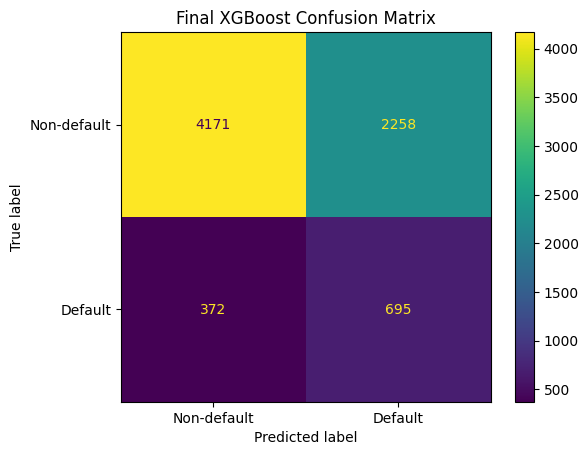

In [48]:
cm = confusion_matrix(y_test, y_test_pred)

cm_display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-default", "Default"]
)

cm_display.plot()
plt.title("Final XGBoost Confusion Matrix")
plt.show()

### Interpretation of the Confusion Matrix

The confusion matrix shows that the final XGBoost model correctly identified **695 of the 1,067 actual default cases**, while **372 defaults were classified as non-defaults**. This corresponds to the model's test-set recall of approximately **65%**.

The model also classified **2,258 non-defaulted loans as defaults**. These false positives explain the relatively low test-set precision of approximately **24%**. In total, the model predicted **2,953 loans as defaults**, compared with 1,067 loans that actually defaulted.

The results therefore reinforce the trade-off observed in the overall performance metrics: the model identifies a meaningful proportion of default cases, but it does so while generating a substantial number of false-positive predictions.

> **NOTE:** The confusion matrix reflects classification decisions at the model's default prediction threshold. Different thresholds would change the balance between false positives and false negatives.

### ROC Curve

The Receiver Operating Characteristic (ROC) curve evaluates the final model's ability to distinguish between defaulted and non-defaulted loans across different classification thresholds.

The curve plots the **True Positive Rate (Recall)** against the **False Positive Rate** as the classification threshold changes.

The **ROC-AUC** summarizes this ranking performance in a single measure. A value closer to 1 indicates stronger discrimination, while a value around 0.5 indicates performance similar to random ranking.

The final model achieved a test-set **ROC-AUC of 0.71**, indicating that the model provides meaningful separation between the two outcome classes.

> **NOTE:** The ROC curve uses the predicted default probabilities from the untouched test dataset. It is used to assess the final model's discrimination and does not affect model selection.

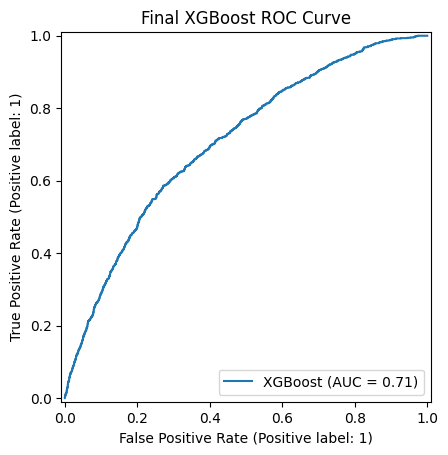

In [49]:
RocCurveDisplay.from_predictions(
    y_test,
    y_test_proba,
    name="XGBoost"
)

plt.title("Final XGBoost ROC Curve")
plt.show()

### Precision-Recall Curve

The Precision-Recall (PR) curve evaluates the trade-off between **precision and recall** across different classification thresholds.

This provides additional insight into the model's performance on the minority **default** class. Unlike the ROC curve, the PR curve focuses directly on the relationship between correctly identified defaults and the false-positive predictions generated by the model.

The curve is particularly useful in this project because defaulted loans represent a smaller proportion of the resolved portfolio than non-defaulted loans.

The final model's **Average Precision of 0.28** summarizes the model's precision-recall performance across thresholds.

> **NOTE:** The PR curve is based on predicted default probabilities from the untouched test dataset. It is used to assess classification performance across thresholds and does not affect model selection.

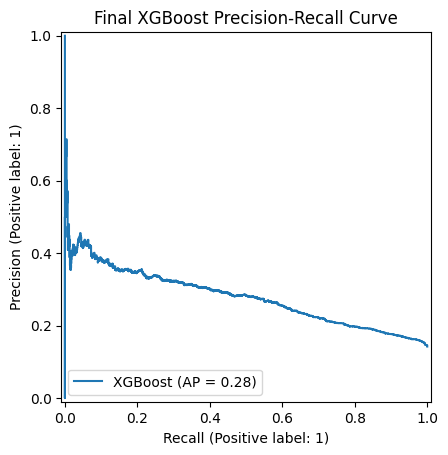

In [50]:
PrecisionRecallDisplay.from_predictions(
    y_test,
    y_test_proba,
    name="XGBoost"
)

plt.title("Final XGBoost Precision-Recall Curve")
plt.show()

### Threshold Analysis

The default classification threshold determines whether a predicted probability is converted into a default or non-default classification.

The model's default threshold produces a recall of approximately **65%** and precision of approximately **24%** on the test set. Examining alternative thresholds illustrates how the balance between identifying defaults and generating false-positive predictions changes.

This is particularly relevant in credit-risk applications, where the relative cost of missed defaults and unnecessary risk flags may differ depending on the business objective.

> **NOTE:** Threshold analysis is presented as an evaluation of the model's behaviour across possible decision thresholds. The test-set results are not used to select a new threshold or refit the model.

In [51]:
thresholds = [0.20, 0.30, 0.40, 0.50, 0.60, 0.70]

threshold_results = []

for threshold in thresholds:
    threshold_pred = (y_test_proba >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Precision": precision_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            threshold_pred,
            zero_division=0
        ),
        "F1-score": f1_score(
            y_test,
            threshold_pred,
            zero_division=0
        )
    })

threshold_results = pd.DataFrame(threshold_results)

threshold_results

,Threshold,Precision,Recall,F1-score
0,0.2000,0.1547,0.9869,0.2675
1,0.3000,0.1690,0.9335,0.2862
2,0.4000,0.1932,0.8247,0.3131
3,0.5000,0.2354,0.6514,0.3458
4,0.6000,0.2945,0.4292,0.3494
5,0.7000,0.3547,0.2127,0.2660


#### Interpretation of Threshold Analysis

As the classification threshold increases, the model becomes more conservative in predicting defaults. Recall decreases while precision generally increases, showing the trade-off between capturing more actual defaults and reducing false-positive predictions.

At the 0.50 threshold, the model achieves 65% recall and 24% precision, which corresponds to the default classification threshold used for the main test-set evaluation.

At a lower threshold of 0.20, recall rises to 99%, but precision falls to 15%, meaning the model identifies almost all defaults while generating many false-positive predictions. At the higher 0.70 threshold, precision increases to 35%, but recall falls to 21%, meaning many actual defaults are missed.

The F1-score peaks around 0.40–0.60 at approximately 0.35, illustrating the balance between precision and recall at these thresholds.

> NOTE: These threshold results are descriptive only. No alternative threshold is selected from the test dataset, preserving the test set as an evaluation dataset.

### Evaluation Summary

The final XGBoost model achieved a **ROC-AUC of 0.71** and **Average Precision of 0.28** on the untouched test dataset. At the default classification threshold, the model achieved **65% recall, 24% precision, and an F1-score of 0.35**.

The results indicate that the model provides useful separation between defaulted and non-defaulted loans and identifies a substantial proportion of actual defaults. However, its relatively low precision means that a considerable number of non-defaulted loans are also classified as potential defaults.

The threshold analysis further demonstrates that increasing recall generally comes at the cost of lower precision, while higher precision is associated with lower recall. This highlights the importance of considering the intended risk-management objective when applying a classification model.

Overall, the test-set results are broadly consistent with the model's cross-validation performance, providing evidence that the selected model retains its predictive behaviour on unseen observations.

> **NOTE:** Model performance is specific to this dataset and evaluation setup. The results should not be assumed to generalise unchanged to other loan portfolios, time periods, or lending populations.

## Model Interpretation

### Feature Importance

Model interpretation is used to understand which borrower and loan characteristics contribute most to the final model's predictions.

Because categorical variables were one-hot encoded during preprocessing, the trained XGBoost model contains multiple encoded features for variables such as purpose, grade, employment length, and state. Reporting these individual encoded categories would make the interpretation difficult to read at the portfolio level.

Therefore, feature importance will first be aggregated back to the original modelling variables. This provides a more interpretable view of the relative contribution of the underlying borrower and loan characteristics.

> **NOTE:** Feature importance describes the variables used by the model and does not establish that a variable independently causes loan default.

In [52]:
# Extract the fitted preprocessing and model components
fitted_pipeline = final_model.best_estimator_

fitted_preprocessor = fitted_pipeline.named_steps["preprocessor"]
fitted_xgb = fitted_pipeline.named_steps["model"]

# Get transformed feature names
feature_names = fitted_preprocessor.get_feature_names_out()

# Get XGBoost feature importances
feature_importances = fitted_xgb.feature_importances_

feature_importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": feature_importances
})

feature_importance_df.head()

,Feature,Importance
0,num__annual_income,0.0181
1,num__dti,0.0088
2,num__installment,0.0088
3,num__int_rate,0.0620
4,num__loan_amount,0.0086


In [53]:
# Remove preprocessing prefixes
feature_importance_df["Original Feature"] = (
    feature_importance_df["Feature"]
    .str.replace(r"^(num__|cat__)", "", regex=True)
    .str.split("_")
    .str[0]
)

# Preserve multi-word / numeric feature names correctly
for feature in numerical_features:
    feature_importance_df.loc[
        feature_importance_df["Feature"] == f"num__{feature}",
        "Original Feature"
    ] = feature

for feature in categorical_features:
    feature_importance_df.loc[
        feature_importance_df["Feature"].str.startswith(f"cat__{feature}_"),
        "Original Feature"
    ] = feature

# Aggregate importance by original modelling variable
aggregated_importance = (
    feature_importance_df
    .groupby("Original Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

aggregated_importance

,Original Feature,Importance
0,address_state,0.2405
11,term_months,0.1735
4,grade,0.1627
10,purpose,0.1240
8,issue_month,0.0840
3,emp_length,0.0662
7,int_rate,0.0620
5,home_ownership,0.0211
1,annual_income,0.0181
13,verification_status,0.0133


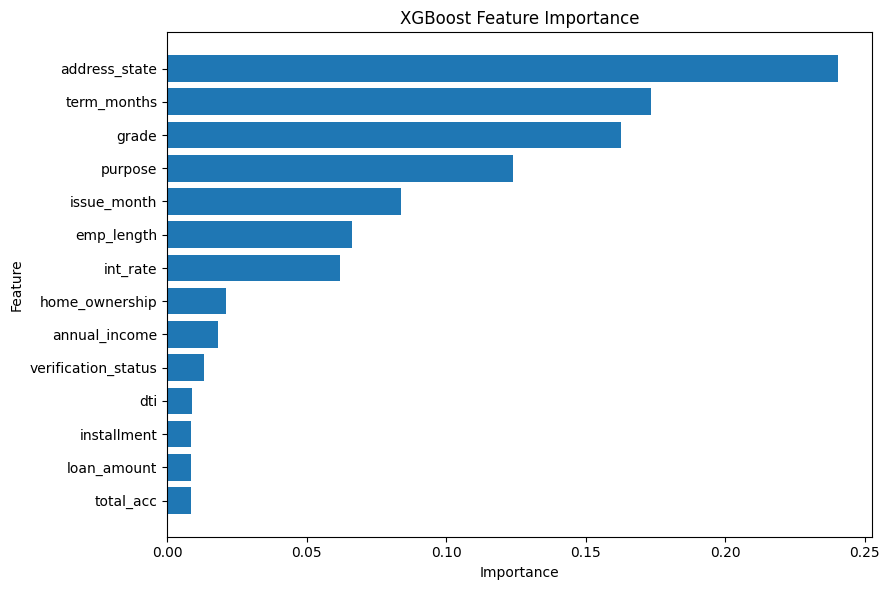

In [54]:
# Plot aggregated XGBoost feature importance
feature_plot = aggregated_importance.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    feature_plot["Original Feature"],
    feature_plot["Importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("XGBoost Feature Importance")
plt.tight_layout()
plt.show()

### Permutation Importance

Permutation importance provides a second perspective on feature relevance by measuring how model performance changes when the values of an individual feature are randomly shuffled.

Unlike the model's built-in feature importance, permutation importance evaluates the contribution of each original modelling variable to predictive performance while accounting for the complete feature-processing pipeline.

This provides a more interpretable assessment of which borrower and loan characteristics are most important to the model's predictive performance.

> **NOTE:** Permutation importance is used for model interpretation only. It does not affect model selection, hyperparameter tuning, or the final model configuration.

In [55]:
# Calculate permutation importance on the untouched test set
perm_importance = permutation_importance(
    final_model.best_estimator_,
    X_test,
    y_test,
    scoring="average_precision",
    n_repeats=10,
    random_state=18,
    n_jobs=-1
)

permutation_importance_df = pd.DataFrame({
    "Feature": X_test.columns,
    "Importance": perm_importance.importances_mean,
    "Std": perm_importance.importances_std
}).sort_values(
    "Importance",
    ascending=False
)

permutation_importance_df

,Feature,Importance,Std
10,int_rate,0.0597,0.0037
5,term_months,0.0327,0.0060
7,annual_income,0.0318,0.0053
4,purpose,0.0164,0.0031
0,address_state,0.0029,0.0016
11,loan_amount,0.0010,0.0016
1,emp_length,0.0009,0.0024
9,installment,0.0006,0.0006
12,total_acc,0.0004,0.0012
3,home_ownership,0.0004,0.0002


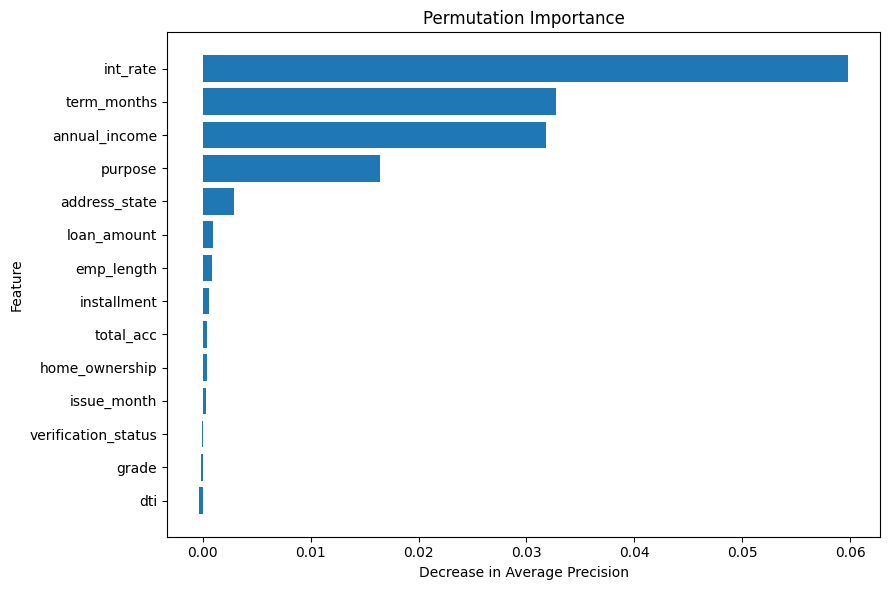

In [56]:
# Plot permutation importance
permutation_plot = permutation_importance_df.sort_values(
    "Importance",
    ascending=True
)

plt.figure(figsize=(9, 6))

plt.barh(
    permutation_plot["Feature"],
    permutation_plot["Importance"]
)

plt.xlabel("Decrease in Average Precision")
plt.ylabel("Feature")
plt.title("Permutation Importance")
plt.tight_layout()
plt.show()

### Feature Importance vs. Permutation Importance

The two feature-importance approaches provide different perspectives on how the final XGBoost model uses the modelling variables.

**Built-in feature importance** measures the contribution of features to the model's tree-based decision process. Because categorical variables are one-hot encoded, the importance of individual categories is aggregated back to their original variables for interpretation.

**Permutation importance** instead measures the change in model performance when the values of an original feature are randomly shuffled. A larger decrease in Average Precision indicates that the model's predictive performance depends more strongly on that feature.

The two approaches produce different rankings in this analysis. Built-in feature importance assigns relatively high importance to **address_state**, while permutation importance shows little change in predictive performance when `address_state` is shuffled. In contrast, **int_rate**, **term_months**, **annual_income**, and **purpose** show more meaningful permutation importance.

This difference demonstrates why feature importance should not be interpreted as a direct measure of the independent importance or causal effect of a variable. The built-in measure reflects how the model uses features within its tree structure, while permutation importance provides a performance-based view of the information contributed by each original variable.

> **NOTE:** Neither measure establishes causality. The results describe how the final model uses the available variables and should be interpreted within the context of this dataset.

### Model Interpretation Summary

The model interpretation results provide two complementary views of feature relevance.

The built-in XGBoost feature importance highlights how the model uses variables within its tree-based decision structure, while permutation importance evaluates how much predictive performance changes when individual original variables are shuffled.

Permutation importance identifies **interest rate, loan term, annual income, and loan purpose** as the variables with the clearest marginal contribution to predictive performance in the test dataset.

The difference between the two approaches also demonstrates that model feature importance should be interpreted carefully, particularly when categorical variables are represented through multiple encoded features.

These results provide insight into the model's predictive behaviour while avoiding the assumption that feature importance represents causal relationships.

> **NOTE:** Feature-importance results are descriptive and specific to the final model and dataset. They should not be interpreted as causal effects or as evidence that changing an individual borrower characteristic would directly change default risk.

## Model Limitations

### Dataset Limitations

The modelling dataset contains **37,478 resolved loans**, with **Fully Paid** loans coded as 0 and **Charged Off** loans coded as 1. Loans with a **Current** status were excluded because their final repayment outcome had not yet been observed. As a result, the model is trained on loans with known historical outcomes and may not fully represent loans that are still in progress.

The final modelling dataset contains **14 predictor variables** covering borrower characteristics, loan characteristics, and origination information. While these variables provide useful information for predicting default, the dataset does not contain every factor that could influence repayment behaviour. Important borrower, credit-history, economic, and macroeconomic information may therefore be absent from the model.

The `address_state` variable contains many categorical values, with some states represented by substantially fewer observations than others. Although rare-category handling was applied during preprocessing, these smaller groups may provide less stable estimates and may limit how confidently state-level patterns can be generalised to other lending populations.

The dataset also contains relatively small groups within some other categorical variables, particularly less common loan purposes, higher-risk grades, and certain employment-length categories. Predictions for these smaller segments may therefore be less reliable than predictions for larger portfolio segments.

The exact `issue_date` was converted to the categorical `issue_month` variable. This reduces the amount of time-related detail available to the model and means that the model does not explicitly capture finer changes in lending conditions within a month.

Because the target represents historical loan outcomes, the model may also be affected by characteristics of the lending environment represented in the dataset. Changes in borrower behaviour, underwriting standards, interest-rate conditions, or broader economic conditions could reduce performance when the model is applied to a different period.

> **NOTE:** The model should therefore be interpreted as a predictive analysis of the available historical dataset rather than a representation of all future borrowers or lending environments.

### Modelling Limitations

The final model uses a relatively limited set of predictors because only variables available in the modelling dataset were retained. Post-origination variables such as `total_payment`, `last_payment_date`, `next_payment_date`, and other variables that could reveal information occurring after loan origination were excluded to reduce the risk of target leakage. This improves the validity of the modelling setup but also means that the model does not use information that may become available later in a loan's lifecycle.

Categorical variables were one-hot encoded, resulting in **107 processed features** from the original 14 modelling variables. This allows the model to capture category-specific patterns but can also make interpretation more difficult, particularly for variables with many categories such as `address_state`.

The modelling process used **5-fold stratified cross-validation**. A larger number of folds or repeated cross-validation could provide additional evidence about the stability of the model's performance, but would also require substantially more model fitting. Given the size of the dataset, the number of hyperparameter combinations evaluated, and available computing resources, 5-fold cross-validation was used as a practical balance between evaluation and computational cost.

The train-test design also used a random stratified split rather than a fully out-of-time validation framework. Therefore, the final test set evaluates performance on held-out observations from the same historical dataset rather than on a genuinely future lending period.

The final XGBoost model achieved useful predictive separation, but its test-set precision remained relatively low. The model identified a substantial proportion of actual defaults, while also producing a considerable number of false-positive classifications. This means that the model's predictions would require careful interpretation rather than being treated as definitive default decisions.

Feature importance and permutation importance also have interpretational limitations. They describe how the model uses the available information but do not establish causal relationships between the predictors and loan default.

> **NOTE:** Further validation using an external or out-of-time dataset, together with additional borrower and economic variables, would provide stronger evidence of model stability and generalisation.

### Business & Analysis Limitations

This project is an **educational machine-learning and portfolio-risk analysis project**. It is designed to demonstrate the application of data analysis, predictive modelling, model evaluation, and risk interpretation techniques. It is not intended to function as a production credit-risk system or as a standalone lending decision system.

The model's predictions should therefore not be interpreted as direct recommendations to approve, reject, price, or otherwise make decisions about individual borrowers. In a real lending environment, model outputs would form only one component of a broader credit-risk and decision-making framework.

A production credit-risk system would require substantially more extensive validation and governance. This could include independent model validation, out-of-time and external testing, monitoring for model drift, documentation of model assumptions and limitations, fairness and bias assessment, explainability requirements, data-quality controls, and appropriate regulatory and institutional review or approval before deployment.

The appropriate classification threshold would also depend on the institution's risk appetite and the relative costs of missed defaults and false-positive risk classifications. The threshold analysis in this project is therefore descriptive and does not establish an operational lending threshold.

The model also does not constitute a complete credit-risk framework. It does not estimate expected credit losses, incorporate recovery or loss-given-default assumptions, perform stress testing, or evaluate the financial consequences of individual lending decisions.

> **NOTE:** The results should be viewed as an educational demonstration of credit-risk modelling techniques and not as evidence that the model is suitable for production lending decisions.

## Final Model & Conclusion

### Final Model

The final model selected for this analysis is a **tuned XGBoost classifier** developed to predict whether a resolved consumer loan would be charged off.

The model was selected through **5-fold stratified cross-validation**, using **Average Precision** as the primary model-selection metric due to the class imbalance in the target variable.

The selected configuration achieved a cross-validation Average Precision of **0.2881**. When evaluated on the previously unseen test dataset, the model achieved:

- **ROC-AUC:** 0.71
- **Average Precision:** 0.28
- **Recall:** 65%
- **Precision:** 24%
- **F1-score:** 0.35
- **Accuracy:** 65%

The model therefore demonstrates useful predictive separation between defaulted and non-defaulted loans, while also producing a substantial number of false-positive default classifications.

The final model and its configuration were fixed before the test-set evaluation. The test dataset was used only to assess the final model's performance and was not used for model selection or hyperparameter tuning.

### Conclusion

This analysis combined **portfolio analytics, SQL analysis, exploratory data analysis, predictive modelling, and model interpretation** to examine consumer loan performance and default risk.

The portfolio analysis identified important patterns in loan exposure, credit quality, loan terms, borrower characteristics, geographic concentration, and realised payment performance. The machine-learning analysis then examined whether these characteristics could be used to distinguish between resolved loans that were fully paid and those that were charged off.

The final XGBoost model achieved a **ROC-AUC of 0.71** and **Average Precision of 0.28** on the held-out test dataset. Its **65% recall** indicates that it identified a substantial proportion of observed default cases, although its **24% precision** also highlights the number of false-positive classifications generated by the model.

The interpretation analysis provided additional insight into the variables used by the model. In particular, permutation importance identified **interest rate, loan term, annual income, and loan purpose** as variables with the clearest marginal contribution to predictive performance within the test dataset.

Overall, the project demonstrates a complete analytical workflow from **portfolio-level analysis to predictive credit-risk modelling and model evaluation**, while explicitly addressing data leakage, class imbalance, model validation, interpretability, and the limitations of applying historical data to future lending decisions.

> **NOTE:** This project is an educational analysis based on a historical dataset. Its results demonstrate the modelling approach and analytical process rather than a production-ready credit-risk solution.